TypeError: unsupported format string passed to PipelineStep.__format__

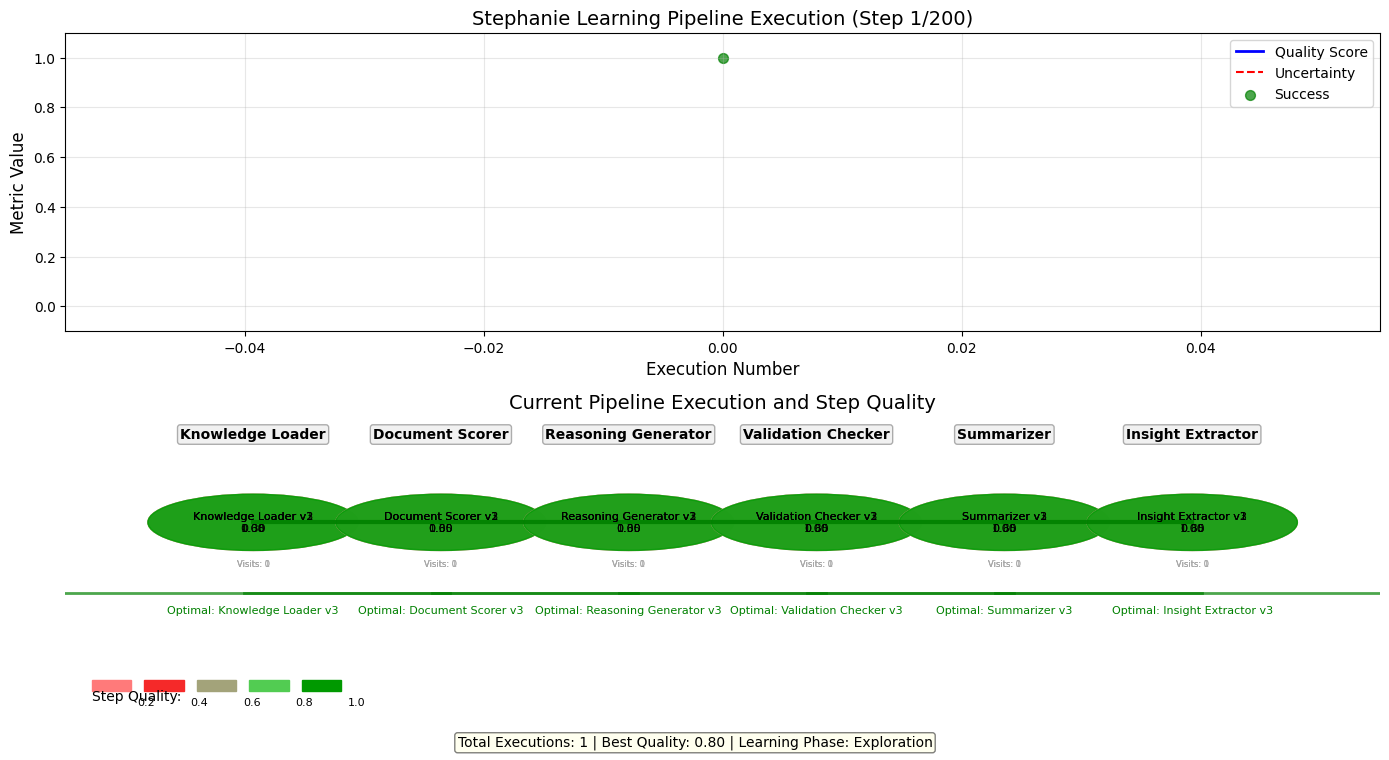

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import imageio
import os
import random
from datetime import datetime
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# Set up output directory
output_dir = "pipeline_frames"
os.makedirs(output_dir, exist_ok=True)

# Create a custom colormap for quality scores
colors = ["#ffcccc", "#ff9999", "#ff6666", "#ff3333", "#cc0000"]  # Red gradient for poor quality
colors += ["#99cc99", "#66cc66", "#33cc33", "#009900"]  # Green gradient for high quality
custom_cmap = LinearSegmentedColormap.from_list("quality_cmap", colors)

class PipelineStep:
    def __init__(self, name, step_type, position):
        self.name = name
        self.step_type = step_type
        self.position = position
        self.visits = 0
        self.quality_score = 0.0
        self.uncertainty = 1.0  # Starts high, decreases with more data
        self.execution_time = 0.5  # Base time in seconds
        self.success_rate = 0.5
        self.is_optimal = False

class PipelineExecution:
    def __init__(self, id, steps):
        self.id = id
        self.steps = steps
        self.timestamp = datetime.now()
        self.overall_quality = 0.0
        self.uncertainty = 1.0
        self.duration = 0.0
        self.success = False
        self.highlighted = False

# Initialize pipeline steps (types of steps Stephanie can use)
step_types = [
    "Knowledge Loader", "Document Scorer", "Reasoning Generator", 
    "Validation Checker", "Summarizer", "Insight Extractor"
]

# Create initial pipeline steps with different qualities
pipeline_steps = []
for i, step_type in enumerate(step_types):
    # Create multiple variants of each step type with different qualities
    for variant in range(3):
        name = f"{step_type} v{variant+1}"
        step = PipelineStep(name, step_type, i)
        # Random quality (higher is better)
        step.quality_score = 0.3 + variant * 0.35
        step.uncertainty = 0.8 - variant * 0.3
        step.success_rate = 0.4 + variant * 0.3
        step.execution_time = 0.4 + (2 - variant) * 0.2
        pipeline_steps.append(step)

# Track all pipeline executions
executions = []
execution_count = 0

# Simulation parameters
total_steps = 200
steps_per_frame = 1
frames = []

# Function to calculate pipeline quality
def calculate_pipeline_quality(steps):
    # Quality is weighted average of step qualities, with penalty for high uncertainty
    total_quality = 0
    total_weight = 0
    
    for step in steps:
        weight = 1.0 - step.uncertainty
        total_quality += step.quality_score * weight
        total_weight += weight
    
    return total_quality / total_weight if total_weight > 0 else 0

# Simulation
for step in range(0, total_steps, steps_per_frame):
    # Create a new pipeline execution
    global execution_count
    execution_count += 1
    selected_steps = []
    
    # Select steps for this execution (with learning over time)
    for pos in range(len(step_types)):
        # Early on: random selection
        # Later: prefer steps with higher quality score and lower uncertainty
        if step < total_steps // 3:
            # Random selection (exploration phase)
            candidates = [s for s in pipeline_steps if s.position == pos]
            selected = random.choice(candidates)
        else:
            # Weighted selection based on quality and uncertainty (exploitation phase)
            candidates = [s for s in pipeline_steps if s.position == pos]
            weights = [(s.quality_score * (1 - s.uncertainty/2)) ** 2 for s in candidates]
            # Normalize weights
            total = sum(weights)
            weights = [w/total if total > 0 else 1/len(weights) for w in weights]
            selected = random.choices(candidates, weights=weights, k=1)[0]
        
        # Record visit
        selected.visits += 1
        
        # Update step statistics based on execution result
        success_prob = selected.success_rate * (1 - selected.uncertainty)
        success = random.random() < success_prob
        
        if success:
            # If successful, slightly improve quality estimate
            improvement = (1.0 - selected.quality_score) * 0.1
            selected.quality_score += improvement
            # Reduce uncertainty
            selected.uncertainty = max(0.05, selected.uncertainty * 0.9)
        
        selected_steps.append(selected)
    
    # Calculate pipeline metrics
    quality = calculate_pipeline_quality(selected_steps)
    uncertainty = sum(s.uncertainty for s in selected_steps) / len(selected_steps)
    duration = sum(s.execution_time for s in selected_steps)
    success = random.random() < (quality * 0.8 + 0.2)  # Pipeline success depends on quality
    
    # Store execution
    execution = PipelineExecution(f"exec_{execution_count}", selected_steps)
    execution.overall_quality = quality
    execution.uncertainty = uncertainty
    execution.duration = duration
    execution.success = success
    executions.append(execution)
    
    # Highlight the best execution so far
    if executions:
        best_execution = max(executions, key=lambda e: e.overall_quality)
        best_execution.highlighted = True
        for e in executions:
            if e != best_execution:
                e.highlighted = False
    
    # Create visualization
    plt.figure(figsize=(14, 8))
    
    # 1. Pipeline Execution History (Top Panel)
    plt.subplot(2, 1, 1)
    
    # Plot quality over time
    qualities = [e.overall_quality for e in executions]
    uncertainties = [e.uncertainty for e in executions]
    successes = [1.0 if e.success else 0.0 for e in executions]
    
    x = range(len(executions))
    
    # Quality line
    plt.plot(x, qualities, 'b-', linewidth=2, label='Quality Score')
    # Uncertainty line
    plt.plot(x, uncertainties, 'r--', linewidth=1.5, label='Uncertainty')
    # Success markers
    plt.scatter(x, successes, c=['g' if s else 'r' for s in successes], 
                s=50, marker='o', alpha=0.7, label='Success')
    
    plt.title(f'Stephanie Learning Pipeline Execution (Step {step + 1}/{total_steps})', fontsize=14)
    plt.xlabel('Execution Number', fontsize=12)
    plt.ylabel('Metric Value', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.ylim(-0.1, 1.1)
    
    # 2. Current Pipeline Visualization (Bottom Panel)
    plt.subplot(2, 1, 2)
    
    # Set up layout
    num_steps = len(step_types)
    y_pos = 0.5
    x_spacing = 1.0 / (num_steps + 1)
    
    # Draw pipeline steps
    step_positions = {}
    for i, step_type in enumerate(step_types):
        x_pos = (i + 1) * x_spacing
        
        # Draw step type header
        plt.text(x_pos, y_pos + 0.25, step_type, 
                 ha='center', va='center', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='lightgray', alpha=0.3, boxstyle='round,pad=0.2'))
        
        # Find the best step for this position (highest quality score)
        candidates = [s for s in pipeline_steps if s.position == i]
        best_step = max(candidates, key=lambda s: s.quality_score * (1 - s.uncertainty))
        
        # Draw all step variants with size/color based on visits and quality
        total_visits = sum(s.visits for s in candidates)
        
        for j, step in enumerate(candidates):
            # Size based on visits (log scale to prevent extreme sizes)
            size = 150 + 300 * (np.log(1 + step.visits) / np.log(1 + max(1, total_visits)))
            
            # Color based on quality score
            color = custom_cmap(step.quality_score)
            
            # Draw step node
            circle = plt.Circle((x_pos, y_pos), 0.08, color=color, alpha=0.8)
            plt.gca().add_patch(circle)
            
            # Add step label
            plt.text(x_pos, y_pos, f"{step.name}\n{step.quality_score:.2f}", 
                     ha='center', va='center', fontsize=8, color='black')
            
            # Add visit count
            plt.text(x_pos, y_pos - 0.12, f"Visits: {step.visits}", 
                     ha='center', va='center', fontsize=6, color='darkgray')
            
            step_positions[step.name] = (x_pos, y_pos)
        
        # Draw optimal path indicator
        plt.plot([x_pos - 0.15, x_pos + 0.15], [y_pos - 0.2, y_pos - 0.2], 
                 'g-', linewidth=2, alpha=0.7)
        plt.text(x_pos, y_pos - 0.25, f"Optimal: {best_step.name}", 
                 ha='center', va='center', fontsize=8, color='green')
    
    # Draw current execution path
    if executions:
        current_execution = executions[-1]
        for i in range(len(current_execution.steps) - 1):
            step1 = current_execution.steps[i]
            step2 = current_execution.steps[i+1]
            
            x1, y1 = step_positions[step1.name]
            x2, y2 = step_positions[step2.name]
            
            # Draw path with thickness based on success
            width = 3.0 if current_execution.success else 1.5
            color = 'green' if current_execution.success else 'red'
            alpha = 0.9 if current_execution.highlighted else 0.5
            
            plt.plot([x1, x2], [y1, y2], color, linewidth=width, alpha=alpha)
    
    # Add legend for step quality
    plt.text(0.02, 0.05, "Step Quality:", transform=plt.gca().transAxes, fontsize=10)
    for i in range(5):
        score = 0.2 + i * 0.2
        x = 0.02 + i * 0.04
        color = custom_cmap(score)
        plt.gca().add_patch(plt.Rectangle((x, 0.02), 0.03, 0.03, color=color))
        plt.text(x + 0.035, 0.035, f"{score:.1f}", transform=plt.gca().transAxes, fontsize=8)
    
    plt.title('Current Pipeline Execution and Step Quality', fontsize=14)
    plt.xlim(0, 1)
    plt.ylim(-0.05, 0.8)
    plt.axis('off')
    
    # Add system information
    info_text = (
        f"Total Executions: {len(executions)} | "
        f"Best Quality: {max([e.overall_quality for e in executions]):.2f} | "
        f"Learning Phase: {'Exploration' if i < total_steps//3 else 'Exploitation'}"
    )
    plt.figtext(0.5, 0.01, info_text, ha='center', fontsize=10, 
                bbox=dict(facecolor='lightyellow', alpha=0.5, boxstyle='round,pad=0.2'))
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save frame
    frame_path = os.path.join(output_dir, f"frame_{i:03d}.png")
    plt.savefig(frame_path, dpi=100, bbox_inches='tight')
    plt.close()
    frames.append(frame_path)

# Combine into GIF
with imageio.get_writer("pipeline_learning.gif", mode='I', duration=0.2) as writer:
    for filename in frames:
        image = imageio.imread(filename)
        writer.append_data(image)

print("✅ Pipeline Execution Learning GIF saved as 'pipeline_learning.gif'")